<a href="https://colab.research.google.com/github/ArgineSahakyan/image-color-clustering/blob/main/image_color_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
print("Hello, ML project!")

Hello, ML project!


In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Apply K-Means clustering to reduce the number of colors in the image
image = Image.open('/content/drive/MyDrive/martirossaryan.jpg')

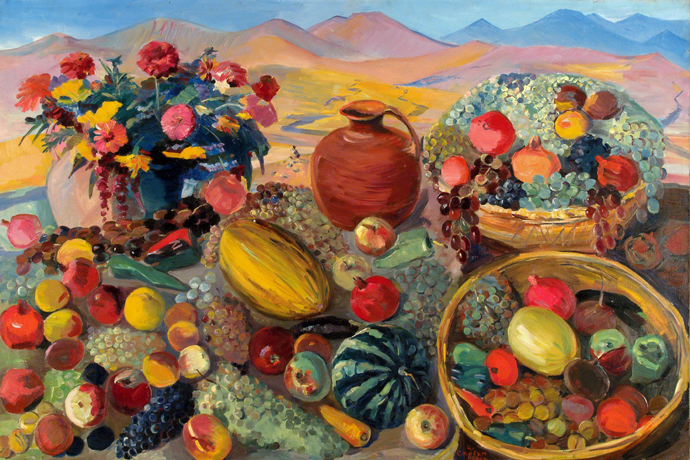

In [14]:
image

In [15]:
image = image.convert('RGB')

In [16]:
image_array=np.array(image)

In [17]:
print(image_array.shape)

(460, 690, 3)


In [18]:
print(image_array[0,0])

[ 96 154 192]


In [19]:
print(image_array.dtype)

uint8


In [20]:
pixels = image_array.reshape(-1, 3)
print(image_array)

[[[ 96 154 192]
  [ 97 156 200]
  [111 164 208]
  ...
  [178 194 184]
  [181 190 185]
  [180 181 165]]

 [[102 163 208]
  [106 165 209]
  [102 164 201]
  ...
  [175 205 205]
  [175 197 194]
  [183 189 177]]

 [[108 166 216]
  [103 166 210]
  [104 165 209]
  ...
  [172 198 199]
  [169 195 192]
  [170 190 179]]

 ...

 [[137 141  82]
  [130 124  74]
  [124 112  62]
  ...
  [105  71  44]
  [ 98  68  34]
  [113 106  64]]

 [[155 177 105]
  [149 174 108]
  [146 173  92]
  ...
  [103  73  49]
  [ 99  86  69]
  [132 120  94]]

 [[151 174  94]
  [151 175  91]
  [156 173  95]
  ...
  [117  82  62]
  [136 112  86]
  [141 117  71]]]


In [21]:
from sklearn.cluster import KMeans

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

In [23]:
labels=kmeans.fit_predict(pixels)

In [24]:
centers = kmeans.cluster_centers_
print(centers)


[[208.65014456 152.92565883  77.62221262]
 [ 55.77242614  43.77866538  40.12343503]
 [161.24179223 172.33559754 179.34057243]
 [115.99536951 114.00888783  91.66704547]
 [154.8106004   70.0556553   41.91832033]]


In [25]:
centers = centers.astype(int)
print(centers)

[[208 152  77]
 [ 55  43  40]
 [161 172 179]
 [115 114  91]
 [154  70  41]]


In [26]:
new_pixels = centers[labels]

In [27]:
new_image = new_pixels.reshape(image_array.shape)

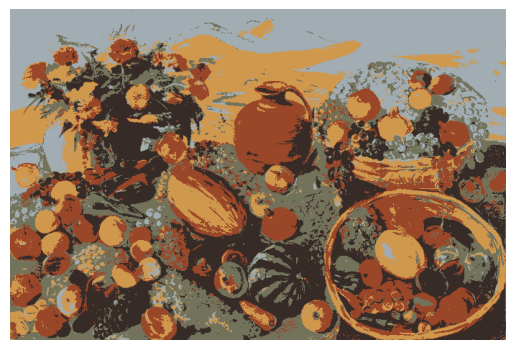

In [28]:
plt.imshow(new_image)
plt.axis('off')
plt.show()

In [29]:
kmeans_16 = KMeans(n_clusters=16, random_state=42, n_init=10)
labels_16 = kmeans_16.fit_predict(pixels)

In [30]:
centers_16 = kmeans_16.cluster_centers_.astype(int)

In [31]:
new_pixels_16 = centers_16[labels_16]

In [32]:
new_image_16 = new_pixels_16.reshape(image_array.shape)

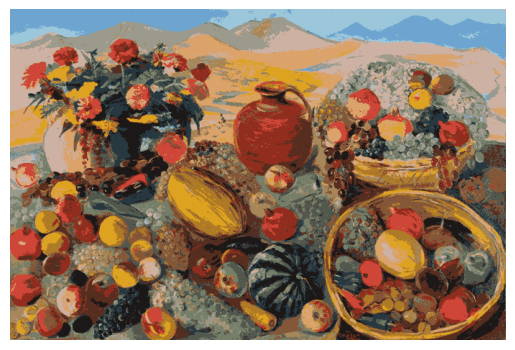

In [33]:
plt.imshow(new_image_16)
plt.axis('off')
plt.show()

In [34]:
# DBSCAN Clustering for Image Color Reduction

In [35]:
from sklearn.cluster import DBSCAN

In [36]:
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(pixels),
    size=10000,
    replace=False
)

sample_pixels = pixels[sample_indices]

In [37]:
print(sample_pixels.shape)

(10000, 3)


In [38]:
dbscan = DBSCAN(eps=10, min_samples=20)
dbscan_labels = dbscan.fit_predict(sample_pixels)

In [39]:
unique_labels = np.unique(dbscan_labels)
print(unique_labels)

[-1  0  1  2  3  4  5  6  7  8]


In [40]:
n_clusters = len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)
print("Number of clusters:", n_clusters)

Number of clusters: 9


In [41]:
n_noise = np.sum(dbscan_labels == -1)
print("Noise points:", n_noise)

Noise points: 2403


In [42]:
for eps_value in [5, 10, 15, 20]:
    dbscan = DBSCAN(eps=eps_value, min_samples=20)
    labels = dbscan.fit_predict(sample_pixels)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        "eps =", eps_value,
        "| clusters =", n_clusters,
        "| noise =", n_noise
    )

eps = 5 | clusters = 11 | noise = 9539
eps = 10 | clusters = 9 | noise = 2403
eps = 15 | clusters = 3 | noise = 264
eps = 20 | clusters = 1 | noise = 16


In [43]:
best_eps = 15

dbscan = DBSCAN(eps=best_eps, min_samples=20)
dbscan_labels = dbscan.fit_predict(sample_pixels)

In [44]:
cluster_labels = np.unique(dbscan_labels)
cluster_labels = cluster_labels[cluster_labels != -1]

print(cluster_labels)

[0 1 2]


In [45]:
dbscan_colors = []

for label in cluster_labels:
    cluster_pixels = sample_pixels[dbscan_labels == label]
    mean_color = cluster_pixels.mean(axis=0)
    dbscan_colors.append(mean_color)

dbscan_colors = np.array(dbscan_colors)

In [46]:
from sklearn.metrics import pairwise_distances_argmin

nearest_color_indices = pairwise_distances_argmin(pixels, dbscan_colors)

In [47]:
dbscan_new_pixels = dbscan_colors[nearest_color_indices]

In [48]:
dbscan_new_pixels = dbscan_new_pixels.astype(np.uint8)

In [49]:
dbscan_image = dbscan_new_pixels.reshape(image_array.shape)

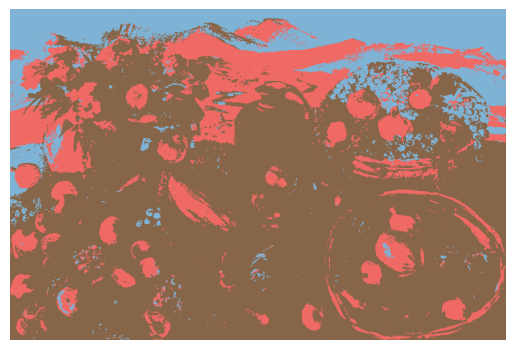

In [50]:
plt.imshow(dbscan_image)
plt.axis('off')
plt.show()

In [51]:
dbscan = DBSCAN(eps=8, min_samples=20)
dbscan_labels = dbscan.fit_predict(sample_pixels)

In [52]:
cluster_labels = np.unique(dbscan_labels)
cluster_labels = cluster_labels[cluster_labels != -1]

In [53]:
dbscan_colors = []

for label in cluster_labels:
    cluster_pixels = sample_pixels[dbscan_labels == label]
    mean_color = cluster_pixels.mean(axis=0)
    dbscan_colors.append(mean_color)

dbscan_colors = np.array(dbscan_colors)

In [54]:
print("Number of representative colors:", len(dbscan_colors))
print(dbscan_colors.astype(int))

Number of representative colors: 17
[[201 164 168]
 [ 80  61  48]
 [126 178 213]
 [236 176   4]
 [214 156 117]
 [123  31  22]
 [162 146 142]
 [158 104  68]
 [153  62  49]
 [ 71  27  26]
 [243 185  90]
 [135 122  92]
 [182 150 128]
 [ 47  64  68]
 [109 126  91]
 [243 185 107]
 [158  56  35]]


In [55]:
from sklearn.metrics import pairwise_distances_argmin

nearest_color_indices = pairwise_distances_argmin(
    pixels,
    dbscan_colors
)

In [56]:
dbscan_new_pixels = dbscan_colors[nearest_color_indices]
dbscan_new_pixels = dbscan_new_pixels.astype(np.uint8)

In [57]:
dbscan_image = dbscan_new_pixels.reshape(image_array.shape)

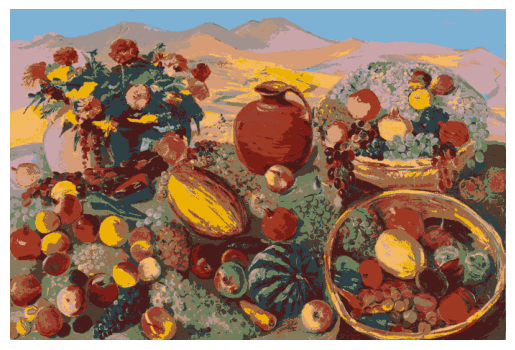

In [58]:
plt.imshow(dbscan_image)
plt.axis('off')
plt.show()

In [59]:
# HDBSCAN Clustering for Image Color Reduction

In [60]:
from sklearn.cluster import HDBSCAN

In [61]:
hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=20
)

In [62]:
hdbscan_labels = hdbscan_model.fit_predict(sample_pixels)

In [63]:
unique_hdbscan_labels = np.unique(hdbscan_labels)
print(unique_hdbscan_labels)

[-1  0  1]


In [64]:
n_hdbscan_clusters = len(set(hdbscan_labels)) - (
    1 if -1 in hdbscan_labels else 0
)

n_hdbscan_noise = np.sum(hdbscan_labels == -1)

print("Number of clusters:", n_hdbscan_clusters)
print("Noise points:", n_hdbscan_noise)

Number of clusters: 2
Noise points: 889


In [65]:
for cluster_size in [30, 50, 80, 100]:
    hdbscan_model = HDBSCAN(
        min_cluster_size=cluster_size,
        min_samples=20
    )

    labels = hdbscan_model.fit_predict(sample_pixels)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        "min_cluster_size =", cluster_size,
        "| clusters =", n_clusters,
        "| noise =", n_noise
    )

min_cluster_size = 30 | clusters = 2 | noise = 889
min_cluster_size = 50 | clusters = 2 | noise = 889
min_cluster_size = 80 | clusters = 2 | noise = 889
min_cluster_size = 100 | clusters = 2 | noise = 889


In [66]:
for min_samples_value in [2, 5, 10, 20]:
    hdbscan_model = HDBSCAN(
        min_cluster_size=30,
        min_samples=min_samples_value
    )

    labels = hdbscan_model.fit_predict(sample_pixels)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        "min_samples =", min_samples_value,
        "| clusters =", n_clusters,
        "| noise =", n_noise
    )

min_samples = 2 | clusters = 2 | noise = 319
min_samples = 5 | clusters = 3 | noise = 1172
min_samples = 10 | clusters = 2 | noise = 950
min_samples = 20 | clusters = 2 | noise = 889


In [67]:
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    cluster_selection_method='leaf'
)

hdbscan_labels = hdbscan_model.fit_predict(sample_pixels)

In [68]:
n_clusters = len(set(hdbscan_labels)) - (
    1 if -1 in hdbscan_labels else 0
)

n_noise = np.sum(hdbscan_labels == -1)

print("Number of clusters:", n_clusters)
print("Noise points:", n_noise)

Number of clusters: 34
Noise points: 7629


In [70]:
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    cluster_selection_method='leaf'
)

hdbscan_labels = hdbscan_model.fit_predict(sample_pixels)

In [71]:
hdbscan_cluster_labels = np.unique(hdbscan_labels)
hdbscan_cluster_labels = hdbscan_cluster_labels[hdbscan_cluster_labels != -1]

In [72]:
hdbscan_colors = []

for label in hdbscan_cluster_labels:
    cluster_pixels = sample_pixels[hdbscan_labels == label]
    mean_color = cluster_pixels.mean(axis=0)
    hdbscan_colors.append(mean_color)

hdbscan_colors = np.array(hdbscan_colors)

In [73]:
from sklearn.metrics import pairwise_distances_argmin

nearest_hdbscan_indices = pairwise_distances_argmin(
    pixels,
    hdbscan_colors
)

In [74]:
hdbscan_new_pixels = hdbscan_colors[nearest_hdbscan_indices]
hdbscan_new_pixels = hdbscan_new_pixels.astype(np.uint8)

In [75]:
hdbscan_image = hdbscan_new_pixels.reshape(image_array.shape)



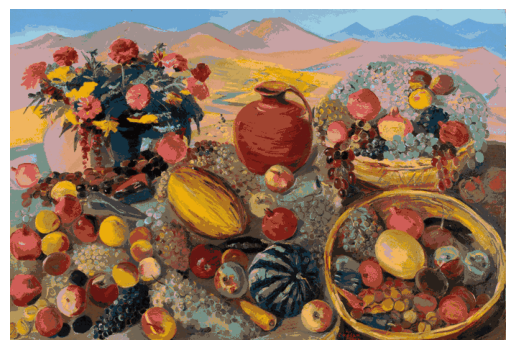

In [76]:
plt.imshow(hdbscan_image)
plt.axis('off')
plt.show()

In [78]:
original_colors = len(np.unique(pixels, axis=0))
kmeans_colors = len(centers_16)
dbscan_color_count = len(dbscan_colors)
hdbscan_color_count = len(hdbscan_colors)

dbscan_noise = np.sum(dbscan_labels == -1)
hdbscan_noise = np.sum(hdbscan_labels == -1)

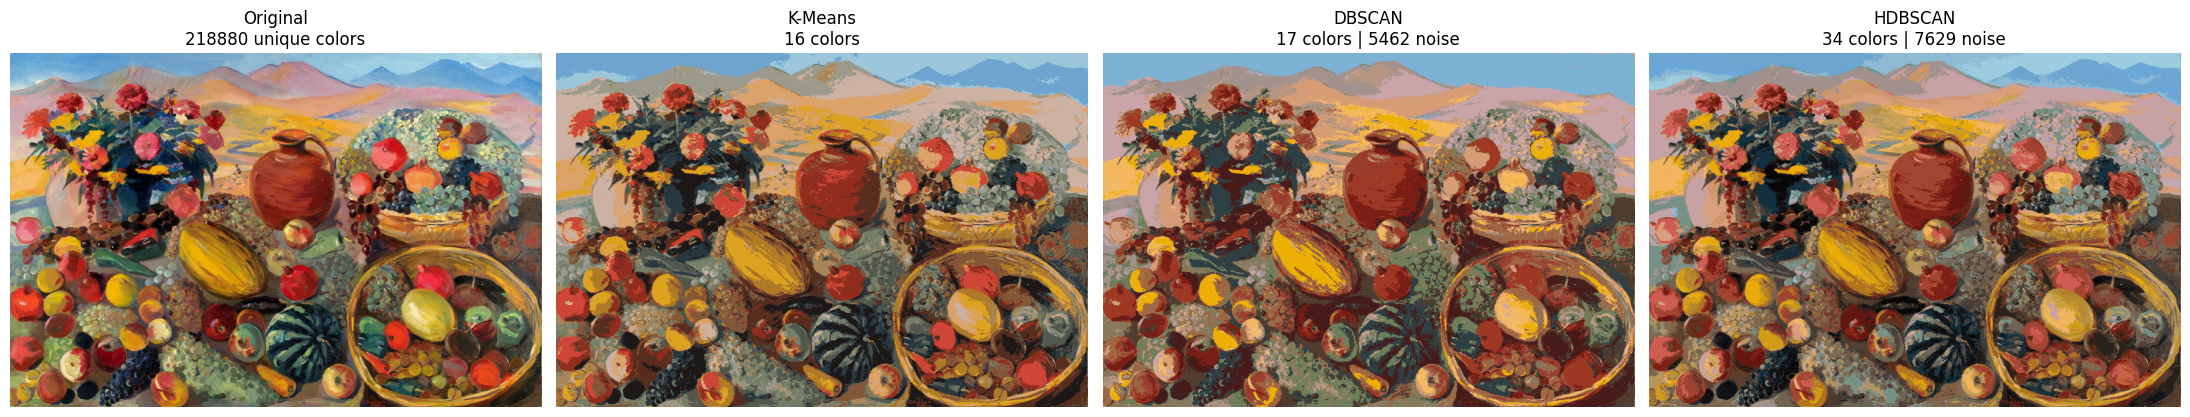

In [79]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# Original
axes[0].imshow(image_array)
axes[0].set_title(
    f"Original\n{original_colors} unique colors"
)
axes[0].axis("off")

# K-Means
axes[1].imshow(new_image_16)
axes[1].set_title(
    f"K-Means\n{kmeans_colors} colors"
)
axes[1].axis("off")

# DBSCAN
axes[2].imshow(dbscan_image)
axes[2].set_title(
    f"DBSCAN\n{dbscan_color_count} colors | {dbscan_noise} noise"
)
axes[2].axis("off")

# HDBSCAN
axes[3].imshow(hdbscan_image)
axes[3].set_title(
    f"HDBSCAN\n{hdbscan_color_count} colors | {hdbscan_noise} noise"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()